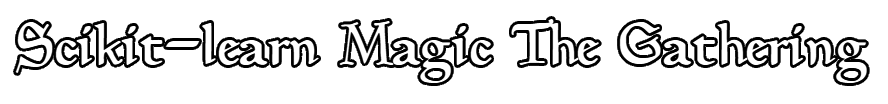

En este trabajo profundizaremos en la libreria Scikit-learn de Python aprendiendo sus funcionalidades principales y aplicandolas en un Dataset especializado en el juego de cartas "Magic The Gathering". El objetivo será predecir los precios con la máxima precisión posible

## 0. Imports
Ejecutamos todos los imports necesarios en nuestro proyecto para tener un código y cuaderno limpio

In [1]:
import io
import requests
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, r2_score

## 1. Introducción
 **Qué es Scikit-learn**<br>
 Es una bibliotecacomputacional dentro del ecosistema cientifico de Python  <br>

 *   **Para qué se utiliza** <br>
 Se utiliza fundamentalmente para construir, entrenar, evaluar y poner en producción modelos de aprendizaje automático (Machine Learning). La herramienta permite crear flujos de trabajo completos que abarcan desde la carga y preparación de los datos hasta la evaluación rigurosa del rendimiento de un modelo computacional.  <br>

 **Tipos de problemas que suele resolver**  <br>



*   Aprendizaje supervisado
  Permite identificar a qué categoría pertenece un conjunto de datos

    * Clasificación: permite identificar a qué categoria pertenece un conjunto de datos (Máquinas de Vectores de Soporte, Naive Bayes...)
    * Regresión: se utiliza para predecir valores continuos o númericos (Regresión Lineal, Procesos Gaussianos...)

  *   Aprendizaje no supervisado <br>
  Sirve para descubrir estructuras, patrones o relaciones ocultas en conjuntos de datos que no tienen etiquetas previas
      * Cluthering: Permite agrupar automáticamente datos que tienen características similares.
      * Reducción de Dimensionalidad: Facilita la visualización y el procesamiento de datos complejos reducioendo la cantidad de variables sin perder mucha información. PCA, t-SNE.
      * Detección de anamolías y novedades: Identifica datos atípicos (outliers) que se desvían de la norma del conjunto de datos.
  *   Transformación y Procesamiento de Datos: resuelve problemas relacionados con la lipieza y adecuación de datos crudos antes de que ingresen a un modelo predictivo
        * Incluye la imputación de valores faltantes, estandarización y normalización de características. Por ejemplo texto o imágenes a datos númericos
      * Encadenar múltiples pasos de transformación utilizando conductos (Pipelines)
*   Selección y evaluación de Modelos: Ofrece herramientas para responder a ¨Qué tan bueno es mi modelo?¨ mediante validación cruzzada y la búsqueda de los hiperparámetros óptimos para maejorar la precision

















## 2. Dataset

In [14]:
# Conectamos con la API de Scryfall: más rápido que subirlo manualmente
# Obtenemos los metadatos
url_configuracion_api = "https://api.scryfall.com/bulk-data/default-cards"
respuesta_servidor = requests.get(url_configuracion_api)
metadatos_archivo_masivo = respuesta_servidor.json()

# Obtenemos los datos
enlace_descarga_cartas = metadatos_archivo_masivo['download_uri']
cartas_dataframe = pd.read_json(enlace_descarga_cartas)

# Output como simple confirmación
print("Dataset cargado correctamente")

Dataset cargado correctamente


## 3. Estructura de los datos.

En Machine Learning, los datos se organizan de forma bidimensional. Nuestro JSON de Scryfall contiene:

*   Filas: cada fila representa una carga de Magic
*   Columnas: Cada columna es una característica de la carta: (nombre, coste, texto, etc.)
*   **Features**
Las Features son las variables independientes que el modelo analiza para encontrar patrones. En Scikit-learn se representan con $X$ debido a que suele ser una matriz 2D.
*   **Target**
El target es la variable dependiente que queremos predecir. En Scikit-learn se representa con $y$ debido a que suele ser un vector 1D.

Dependiendo de que queramos que haga nuestro modelo el target cambiará. En este caso usaremos Regresión para predecir el Precio según las características de la carta

## 4. Limpieza Inicial y Definición del Alcance
El dataset de Scryfall contiene más de 100.000 registros. Sin embargo, no todas las cartas son útiles para nuestro modelo predictivo basado en estadísticas de combate (Fuerza y Resistencia).

**Criterios de exclusión:**
1. **Tipos de carta incompatibles:** Se descartan Tierras, Conjuros, Instantáneos, Artefactos y Encantamientos, ya que carecen de valores de Fuerza (`power`) y Resistencia (`toughness`).
2. **Estadísticas variables:** Se descartan aquellas criaturas cuya fuerza o resistencia depende de variables en partida (marcadas con `*` o `X` en su texto), ya que un modelo numérico no puede interpretarlas de forma estática.
3. **Cartas promocionales o "Un-sets":** Nos centramos en cartas de juego estándar (Core sets y Expansiones normales).

A continuación, aplicamos estos filtros y visualizamos el impacto en nuestro volumen de datos.

Cartas en el dataset original: 112632
Cartas tras aplicar filtro: 19952
Cartas descartadas: 92680


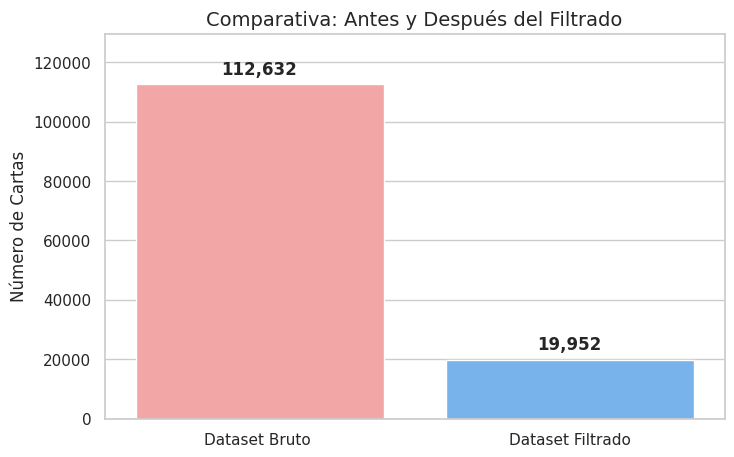

In [19]:
# Guardamos el tamaño original del dataset
cantidad_total_original = len(cartas_dataframe)

# Aplicamos filtros
#   1. Solo criaturas
criaturas_filtradas_dataframe = cartas_dataframe[cartas_dataframe['type_line'].str.contains('Creature', na=False)].copy()

#   2. estadísticas variables (* o +)
criaturas_filtradas_dataframe = criaturas_filtradas_dataframe[~criaturas_filtradas_dataframe['power'].astype(str).str.contains(r'\*|\+', na=False)]
criaturas_filtradas_dataframe = criaturas_filtradas_dataframe[~criaturas_filtradas_dataframe['toughness'].astype(str).str.contains(r'\*|\+', na=False)]

#   3.sets principales  ('core', 'expansion')
tipos_de_sets_permitidos = ['core', 'expansion']
criaturas_filtradas_dataframe = criaturas_filtradas_dataframe[criaturas_filtradas_dataframe['set_type'].isin(tipos_de_sets_permitidos)].copy()

# guardamos el tamaño del dataset filtrado
cantidad_total_filtrada = len(criaturas_filtradas_dataframe)

# obtenemos y guardamos la cantidad de cartas filtradas
cantidad_cartas_descartadas = cantidad_total_original - cantidad_total_filtrada

print(f"Cartas en el dataset original: {cantidad_total_original}")
print(f"Cartas tras aplicar filtro: {cantidad_total_filtrada}")
print(f"Cartas descartadas: {cantidad_cartas_descartadas}")

# Creamos un gráfico de barras para comparar
plt.figure(figsize=(8, 5))
sns.barplot(
    x=['Dataset Bruto ', 'Dataset Filtrado'],
    y=[cantidad_total_original, cantidad_total_filtrada],
    hue=['Dataset Bruto ', 'Dataset Filtrado'],
    palette=['#ff9999', '#66b3ff'],
    legend=False
)

plt.title('Comparativa: Antes y Después del Filtrado', fontsize=14)
plt.ylabel('Número de Cartas')

# Añadimos etiquetas encima de las barras
plt.text(0, cantidad_total_original + 2000, f"{cantidad_total_original:,}", ha='center', va='bottom', fontweight='bold')
plt.text(1, cantidad_total_filtrada + 2000, f"{cantidad_total_filtrada:,}", ha='center', va='bottom', fontweight='bold')

# Margen por arriba
plt.ylim(0, cantidad_total_original * 1.15)
plt.show()

## 5. Separación de Datos
Es importante dividir el conjunto de datos original en dos subgrupos independientes. En Scikit-learn se usa *train_test_split*


Si evaluamos el modelo con los mismos datos que usamos para entrenarlo no sabra como se comportará ante datos del ¨mundo real¨ que nunca ha visto. A esto lo llamamos **Overfitting**

*   Training Set : Es la proporción de datos que se entrega al algoritmo

*   Test set: Es una porción de datos que se mantiene oculta al modelo durante el entrenamiento. Se usa para medir la precisión real del modelo.



## 6. Exploración de Datos (EDA)

Antes de entrenar nuestro algoritmo, es fundamental entender la distribución y el comportamiento de nuestra variable objetivo (`target_price`). En un mercado de coleccionismo como Magic: The Gathering, los precios no suelen seguir una distribución normal o de campana de Gauss, lo cual dificulta nuestra predicción para el Machine Learning.

A continuación, generamos dos visualizaciones clave para diagnosticar el estado de nuestros datos:

1. **Boxplot por Rareza (Escala Logarítmica):** Nos permite observar si existe una correlación inicial entre la rareza impresa de la carta y su precio: nos revelará la presencia de **valores atípicos (outliers)**: puntos que se escapan drásticamente por encima de las cajas, representando cartas de coleccionista con precios desorbitados.
2. **Histograma de Distribución de Precios:** Demuestra visualmente la asimetría extrema (asimetría positiva) del mercado. La inmensa mayoría de las cartas se agrupan en valores muy bajos (céntimos o pocos dólares), mientras que una larga "cola" se extiende hacia la derecha.

**Diagnóstico previo al modelado:** Si introducimos estos datos "en bruto" a un algoritmo de regresión, este intentará minimizar el error frente a las cartas de 100EUR o 200EUR, distorsionando por completo las predicciones. Esta exploración justifica la necesidad estadística de aplicar un **recorte de dominio (marcado por la línea roja)**.

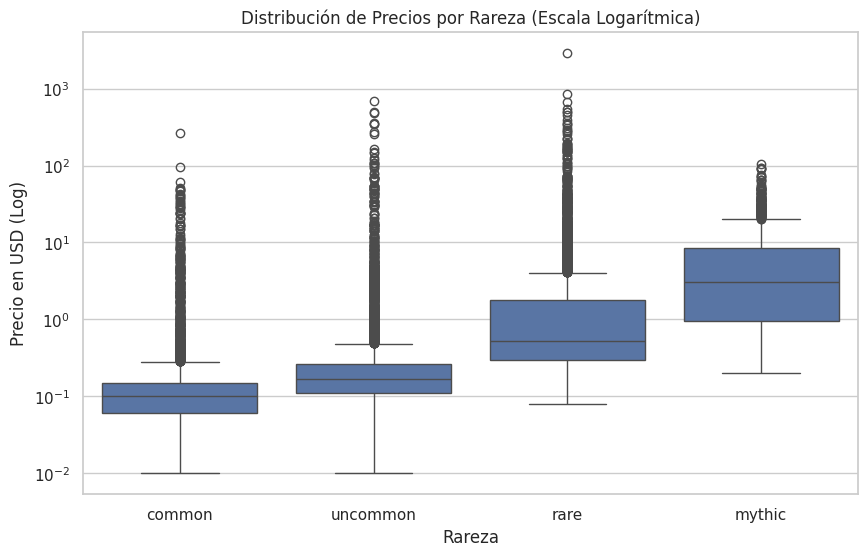

In [20]:
# Configuración gráfica
sns.set_theme(style="whitegrid")

# Usamos los datos filtrados
criaturas_filtradas_dataframe['target_price'] = pd.to_numeric(criaturas_filtradas_dataframe['prices'].apply(lambda x: x.get('usd')), errors='coerce')
criaturas_filtradas_dataframe = criaturas_filtradas_dataframe.dropna(subset=['target_price'])

# BOXPLOT
#Identificación de Outliers
plt.figure(figsize=(10, 6))
sns.boxplot(x='rarity', y='target_price', data=criaturas_filtradas_dataframe, order=['common', 'uncommon', 'rare', 'mythic'])
plt.title('Distribución de Precios por Rareza (Escala Logarítmica)')
plt.ylabel('Precio en USD (Log)')
plt.xlabel('Rareza')
plt.yscale('log')
plt.show()

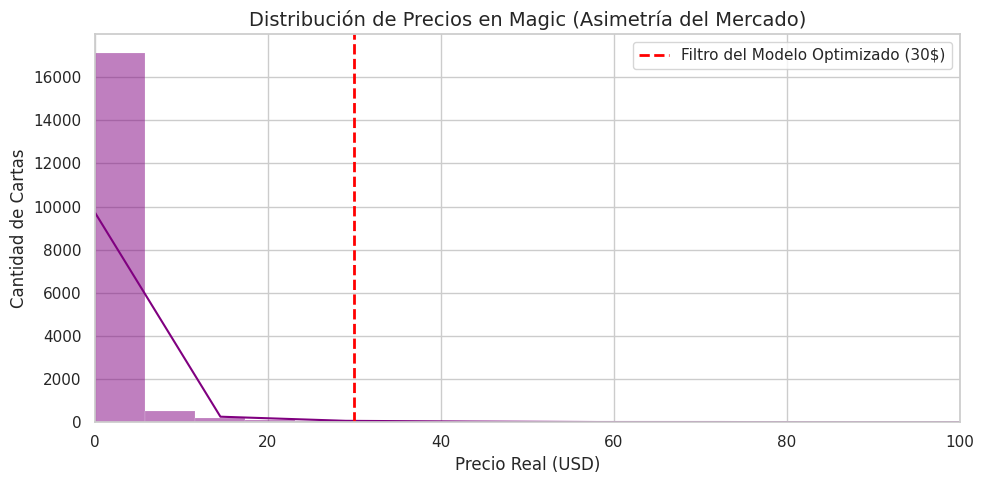

In [21]:
# HISTOGRAMA: Distribución General de Precios ---
plt.figure(figsize=(10, 5))

# Creamos el histograma, limitando el eje X a 100$ para que se vea bien la acumulación
sns.histplot(data=criaturas_filtradas_dataframe, x='target_price', bins=500, color='purple', kde=True)
plt.xlim(0, 100)

plt.title('Distribución de Precios en Magic (Asimetría del Mercado)', fontsize=14)
plt.xlabel('Precio Real (USD)')
plt.ylabel('Cantidad de Cartas')

# Dibujamos una línea roja donde haremos nuestro recorte de outliers más adelante
plt.axvline(30, color='red', linestyle='--', linewidth=2, label='Filtro del Modelo Optimizado (30$)')
plt.legend()

plt.tight_layout()
plt.show()

## 7. Desarrollo y Optimización del Modelo

### 7.1 Primera Iteración: Modelo Base (Naïve)
En Ciencia de Datos, es una buena práctica entrenar primero un "Modelo Base" utilizando todos los datos disponibles sin filtrar, para establecer un punto de partida. A continuación, procesamos el dataset completo, incluyendo las cartas de valores extremos (outliers).

Una vez tenemos los datos divididos, debemos explicar que transformaciones aplicamos antes de pasarlos por el modelo. Scikit-learn requiere que todos los datos de entrada sean numéricos y estén limpios.

Técnicas que debemos incluir en nustro Dataset:


*   Data Cleaning <br>
    Muchas cartas no tienen fuerza o resistencia (como las cartas de Conjuro)
*   Label Encoding <br>
  variable objetivo. Precio.

*   Feature Scaling <br>
  Modificar el rango de las variables para que coincidan entre los diferentes tipos
  



In [22]:
# Preparación de variables numéricas
criaturas_base_dataframe = criaturas_filtradas_dataframe.copy()
criaturas_base_dataframe['power_num'] = pd.to_numeric(criaturas_base_dataframe['power'], errors='coerce')
criaturas_base_dataframe['toughness_num'] = pd.to_numeric(criaturas_base_dataframe['toughness'], errors='coerce')
criaturas_base_dataframe['color_count'] = criaturas_base_dataframe['colors'].apply(lambda x: len(x) if isinstance(x, list) else 0)
criaturas_base_dataframe['text_len'] = criaturas_base_dataframe['oracle_text'].apply(lambda x: len(str(x)) if x else 0)
criaturas_base_dataframe['rarity_num'] = criaturas_base_dataframe['rarity'].map({'common': 0, 'uncommon': 1, 'rare': 2, 'mythic': 3}).fillna(0)

# Definición de X e y usando todas las cartas sin limites de precio
lista_caracteristicas = ['cmc', 'power_num', 'toughness_num', 'rarity_num', 'text_len', 'color_count']
matriz_caracteristicas_base = criaturas_base_dataframe[lista_caracteristicas].copy()
variable_objetivo_precio_base = criaturas_base_dataframe['target_price'].copy()

# Limpieza de nulos y separación (Train/Test)
imputador_valores_nulos = SimpleImputer(strategy='constant', fill_value=0)
matriz_caracteristicas_base[['power_num', 'toughness_num']] = imputador_valores_nulos.fit_transform(matriz_caracteristicas_base[['power_num', 'toughness_num']])

caracteristicas_entrenamiento_base, caracteristicas_prueba_base, objetivo_entrenamiento_base, objetivo_prueba_base = train_test_split(
    matriz_caracteristicas_base, variable_objetivo_precio_base, test_size=0.2, random_state=42
)

# Escalado y Entrenamiento
escalador_estandar_base = StandardScaler()
caracteristicas_entrenamiento_base_escaladas = escalador_estandar_base.fit_transform(caracteristicas_entrenamiento_base)
caracteristicas_prueba_base_escaladas = escalador_estandar_base.transform(caracteristicas_prueba_base)

modelo_bosque_aleatorio_base = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_bosque_aleatorio_base.fit(caracteristicas_entrenamiento_base_escaladas, objetivo_entrenamiento_base)

# Resultado
predicciones_precio_base = modelo_bosque_aleatorio_base.predict(caracteristicas_prueba_base_escaladas)
print(f"--- RESULTADOS MODELO BASE (Con Outliers) ---")
print(f"MAE: {mean_absolute_error(objetivo_prueba_base, predicciones_precio_base):.2f} USD")
print(f"R2: {r2_score(objetivo_prueba_base, predicciones_precio_base):.2f}")

--- RESULTADOS MODELO BASE (Con Outliers) ---
MAE: 3.65 USD
R2: -0.23


Obteniendo un $R^2$ negativo y un error alto.  Esto se debe a que el algoritmo *Random Forest* intenta no equivocarse en las cartas de coleccionista de más de 100$ (los outliers que vimos en el Boxplot), distorsionando las predicciones de las cartas normales.

A continuación desarrollaremos una versión optimizada limpiando nuestros datos para posteriormente compararlo con nuestro dataset "base".

### 7.2 Diagnóstico y Segunda Iteración: Modelo Optimizado
Aplicamos un "recorte de dominio" limitando el entrenamiento cartas de $\le$ 30 USD.

In [24]:
# Filtramos las cartas caras
criaturas_modelo_optimizado_dataframe = criaturas_filtradas_dataframe[criaturas_filtradas_dataframe['target_price'] <= 30.0].copy()

# Usamos las mismas variables numéricas
criaturas_modelo_optimizado_dataframe['power_num'] = pd.to_numeric(criaturas_modelo_optimizado_dataframe['power'], errors='coerce')
criaturas_modelo_optimizado_dataframe['toughness_num'] = pd.to_numeric(criaturas_modelo_optimizado_dataframe['toughness'], errors='coerce')
criaturas_modelo_optimizado_dataframe['color_count'] = criaturas_modelo_optimizado_dataframe['colors'].apply(lambda x: len(x) if isinstance(x, list) else 0)
criaturas_modelo_optimizado_dataframe['text_len'] = criaturas_modelo_optimizado_dataframe['oracle_text'].apply(lambda x: len(str(x)) if x else 0)
criaturas_modelo_optimizado_dataframe['rarity_num'] = criaturas_modelo_optimizado_dataframe['rarity'].map({'common': 0, 'uncommon': 1, 'rare': 2, 'mythic': 3}).fillna(0)

# Definimos X e Y
matriz_caracteristicas_optimizado = criaturas_modelo_optimizado_dataframe[lista_caracteristicas].copy()
variable_objetivo_precio_optimizado = criaturas_modelo_optimizado_dataframe['target_price'].copy()

# Rellenamos nulos, separamos y escalamos
matriz_caracteristicas_optimizado[['power_num', 'toughness_num']] = imputador_valores_nulos.transform(matriz_caracteristicas_optimizado[['power_num', 'toughness_num']])

caracteristicas_entrenamiento_optimizado, caracteristicas_prueba_optimizado, objetivo_entrenamiento_optimizado, objetivo_prueba_optimizado = train_test_split(
    matriz_caracteristicas_optimizado, variable_objetivo_precio_optimizado, test_size=0.2, random_state=42
)

escalador_estandar_optimizado = StandardScaler()
caracteristicas_entrenamiento_optimizado_escaladas = escalador_estandar_optimizado.fit_transform(caracteristicas_entrenamiento_optimizado)
caracteristicas_prueba_optimizado_escaladas = escalador_estandar_optimizado.transform(caracteristicas_prueba_optimizado)

# Entrenamos el nuevo modelo optimizado
modelo_mtg_optimizado = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_mtg_optimizado.fit(caracteristicas_entrenamiento_optimizado_escaladas, objetivo_entrenamiento_optimizado)

# Resultado
predicciones_precio_optimizado = modelo_mtg_optimizado.predict(caracteristicas_prueba_optimizado_escaladas)
print(f"--- RESULTADOS MODELO OPTIMIZADO (Cartas <= 30$) ---")
print(f"Nuevo MAE: {mean_absolute_error(objetivo_prueba_optimizado, predicciones_precio_optimizado):.2f} USD")
print(f"Nuevo R2: {r2_score(objetivo_prueba_optimizado, predicciones_precio_optimizado):.2f}")

--- RESULTADOS MODELO OPTIMIZADO (Cartas <= 30$) ---
Nuevo MAE: 1.11 USD
Nuevo R2: 0.22


### 7.2.1 Ejemplo de Predicción con Carta Nueva

Comparamos nuestro módelo filtrado y sin filtrar:

In [26]:
print("\nPredicción para una carta inventada (Fuerza 5, Resistencia 5, Coste 4, Rara):")

# Definimos explícitamente el nombre de las columnas para evitar errores de memoria
lista_nombres_columnas = ['cmc', 'power_num', 'toughness_num', 'rarity_num', 'text_len', 'color_count']

# Creamos la carta con: cmc=4, power=5, toughness=5, rarity=2 (Rara), text_len=100, color_count=1
datos_carta_nueva_dataframe = pd.DataFrame([[4, 5, 5, 2, 100, 1]], columns=lista_nombres_columnas)

# Modelo Base
# Usamos el scaler_b y el modelo_base que entrenamos en el apartado 7.1
datos_carta_nueva_escalados_base = escalador_estandar_base.transform(datos_carta_nueva_dataframe)
precio_predicho_modelo_base = modelo_bosque_aleatorio_base.predict(datos_carta_nueva_escalados_base)

# Modelo Optimizado
# Usamos el scaler y el modelo_mtg del apartado 7.2
datos_carta_nueva_escalados_optimizado = escalador_estandar_optimizado.transform(datos_carta_nueva_dataframe)
precio_predicho_modelo_optimizado = modelo_mtg_optimizado.predict(datos_carta_nueva_escalados_optimizado)

# Resultados
print("-" * 60)
print(f"El Modelo Base : {precio_predicho_b[0]:.2f} USD")
print(f"El Modelo Optimizado :      {precio_predicho[0]:.2f} USD")
print("-" * 60)



Predicción para una carta inventada (Fuerza 5, Resistencia 5, Coste 4, Rara):
------------------------------------------------------------
El Modelo Base : 3.53 USD
El Modelo Optimizado :      2.56 USD
------------------------------------------------------------


### 7.3 Comparativa Visual de los Modelos
Para poner en perspectiva el impacto de nuestra limpieza de datos y del recorte de dominio (eliminar cartas > 30$), vamos a comparar visualmente las métricas del Modelo Base frente a las del Modelo Optimizado.

Como veremos, el Error Absoluto Medio (MAE) se desploma, y el Coeficiente de Determinación ($R^2$) pasa de ser negativo (un modelo inservible) a un valor positivo, demostrando que el algoritmo por fin ha captado la relación subyacente entre las mecánicas de la carta y su precio.

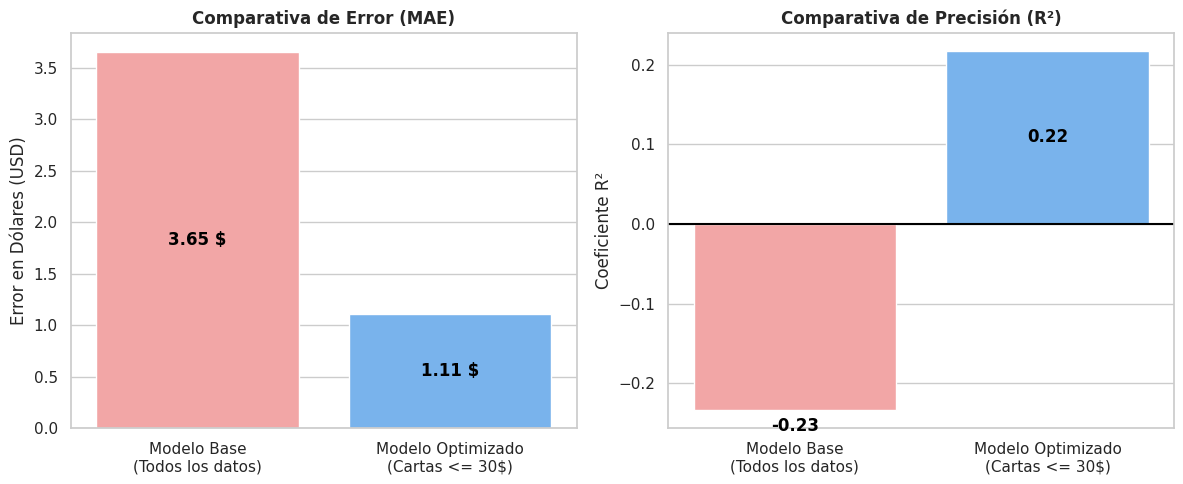

In [28]:
# Calculamos las métricas exactas basándonos en las predicciones anteriores
error_absoluto_medio_base = mean_absolute_error(objetivo_prueba_base, predicciones_precio_base)
coeficiente_r2_base = r2_score(objetivo_prueba_base, predicciones_precio_base)
error_absoluto_medio_optimizado = mean_absolute_error(objetivo_prueba_optimizado, predicciones_precio_optimizado)
coeficiente_r2_optimizado = r2_score(objetivo_prueba_optimizado, predicciones_precio_optimizado)

# Preparamos la figura con 2 subgráficos 1 fila, 2 columnas
figura_comparativa, ejes_graficos = plt.subplots(1, 2, figsize=(12, 5))

# Definimos los nombres de los grupos para evitar repetición
nombres_modelos = ['Modelo Base\n(Todos los datos)', 'Modelo Optimizado\n(Cartas <= 30$)']

# Gráfico 1
# Correción del Warning
sns.barplot(x=nombres_modelos,
            y=[error_absoluto_medio_base, error_absoluto_medio_optimizado],
            hue=nombres_modelos,
            palette=['#ff9999', '#66b3ff'],
            ax=ejes_graficos[0],
            legend=False)

ejes_graficos[0].set_title('Comparativa de Error (MAE)', fontsize=12, fontweight='bold')
ejes_graficos[0].set_ylabel('Error en Dólares (USD)')

# Ponemos el numerito dentro de la barra
ejes_graficos[0].text(0, error_absoluto_medio_base / 2, f"{error_absoluto_medio_base:.2f} $", ha='center', va='center', fontweight='bold', fontsize=12, color='black')
ejes_graficos[0].text(1, error_absoluto_medio_optimizado / 2, f"{error_absoluto_medio_optimizado:.2f} $", ha='center', va='center', fontweight='bold', fontsize=12, color='black')

# Gráfico 2
# Correción del Warning
sns.barplot(x=nombres_modelos,
            y=[coeficiente_r2_base, coeficiente_r2_optimizado],
            hue=nombres_modelos,
            palette=['#ff9999', '#66b3ff'],
            ax=ejes_graficos[1],
            legend=False)

ejes_graficos[1].set_title('Comparativa de Precisión (R²)', fontsize=12, fontweight='bold')
ejes_graficos[1].set_ylabel('Coeficiente R²')

# Dibujamos una línea negra en el 0
ejes_graficos[1].axhline(0, color='black', linewidth=1.5)

# Ajustamos la posición del texto
posicion_texto_r2_base = coeficiente_r2_base - 0.02 if coeficiente_r2_base < 0 else coeficiente_r2_base / 2
ejes_graficos[1].text(0, posicion_texto_r2_base, f"{coeficiente_r2_base:.2f}", ha='center', va='center', fontweight='bold', fontsize=12, color='black')
ejes_graficos[1].text(1, coeficiente_r2_optimizado / 2, f"{coeficiente_r2_optimizado:.2f}", ha='center', va='center', fontweight='bold', fontsize=12, color='black')

plt.tight_layout()
plt.show()

## 8. Visualización de Resultados
Usaremos un Gráfico de Dispersión "Scatter Plot" que compara los precios reales frente a los predichos

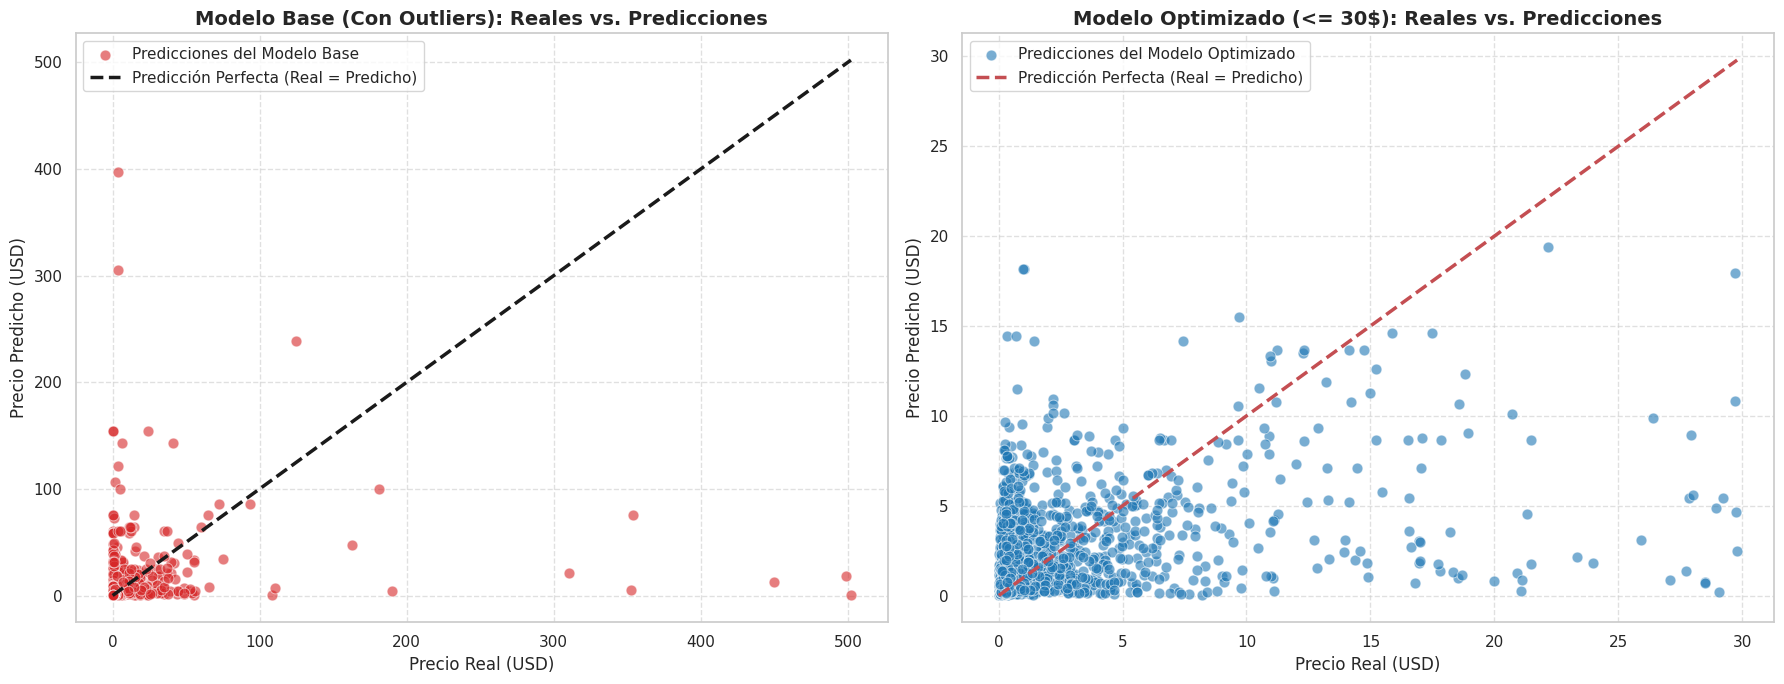

In [31]:
# Creamos una figura con 2 subgráficos (1 fila, 2 columnas)
figura_comparativa_predicciones, ejes_visualizacion = plt.subplots(1, 2, figsize=(18, 7))

# Gráfico 1
# Usamos el primer eje [0]
sns.scatterplot(
    x=objetivo_prueba_base,
    y=predicciones_precio_base,
    alpha=0.6,
    color='#d62728',    # Rojo profesional (alerta/error)
    edgecolor='white',
    s=60,
    label='Predicciones del Modelo Base',
    ax=ejes_visualizacion[0]
)

# Añadimos la línea ideal
ejes_visualizacion[0].plot(
    [objetivo_prueba_base.min(), objetivo_prueba_base.max()],
    [objetivo_prueba_base.min(), objetivo_prueba_base.max()],
    '--k',              # Línea negra punteada para contrastar con el rojo
    linewidth=2.5,
    label='Predicción Perfecta (Real = Predicho)'
)

# Textos y estilo para el primer gráfico
ejes_visualizacion[0].set_title('Modelo Base (Con Outliers): Reales vs. Predicciones', fontsize=14, fontweight='bold')
ejes_visualizacion[0].set_xlabel('Precio Real (USD)', fontsize=12)
ejes_visualizacion[0].set_ylabel('Precio Predicho (USD)', fontsize=12)
ejes_visualizacion[0].legend(loc='upper left', fontsize=11)
ejes_visualizacion[0].grid(True, linestyle='--', alpha=0.6)


# Gráfico 2
# Usamos el segundo eje [1]
sns.scatterplot(
    x=objetivo_prueba_optimizado,
    y=predicciones_precio_optimizado,
    alpha=0.6,          # Transparencia para ver dónde se acumulan los puntos
    color='#1f77b4',    # Azul profesional
    edgecolor='white',  # Borde blanco para separar los puntos solapados
    s=60,               # Tamaño un poco más grande
    label='Predicciones del Modelo Optimizado',
    ax=ejes_visualizacion[1]
)

# Añadimos una línea ideal
ejes_visualizacion[1].plot(
    [objetivo_prueba_optimizado.min(), objetivo_prueba_optimizado.max()],
    [objetivo_prueba_optimizado.min(), objetivo_prueba_optimizado.max()],
    '--r',
    linewidth=2.5,
    label='Predicción Perfecta (Real = Predicho)'
)

# Textos y estilo para el segundo gráfico
ejes_visualizacion[1].set_title('Modelo Optimizado (<= 30$): Reales vs. Predicciones', fontsize=14, fontweight='bold')
ejes_visualizacion[1].set_xlabel('Precio Real (USD)', fontsize=12)
ejes_visualizacion[1].set_ylabel('Precio Predicho (USD)', fontsize=12)
ejes_visualizacion[1].legend(loc='upper left', fontsize=11)
ejes_visualizacion[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## 9. Conclusión

En un mercado tan volatil como el de Magic The Gathering hay muchas variables a tener en cuenta, no podemos únicamente hacer una simple predicción usando las variables base de las cartas. Aunque la carta "Anillo Único" del set del Señor de los Anillos ha sido una unidad poderosa en el formato Modern su valor de venta (que fue de 2 millones de dolares) se aleja mucho de su valor dentro del juego debido a todo lo que lo rodea : escacez, fandom, arte, hype...
Por eso al hacer un filtraje y predecir únicamente las criaturas con valores fijos nuestra predicción ha mejorado sustancialmente. <br>
Posibles incorporaciones en el futuro:


*   Predicción básica de conjuros
*   Algoritmo de relación entre universos alternativos (Warhammer, Marvel, LOTR...) y precio de mercado
*   Incluir, de manera simplificada para no ensuciar los datos, las +100 keywords existentes en el juego



## 10. Bibliografía
* **Scikit-learn Developers. (s.f.).** *User Guide*. Recuperado de https://scikit-learn.org/stable/user_guide.html
* **Scikit-learn Developers. (s.f.).** *Importance of Feature Scaling*. Recuperado de https://scikit-learn.org/stable/auto_examples/preprocessing/plot_scaling_importance.html
* **Pandas Development Team. (s.f.).** *Intro to Data Structures*. Recuperado de https://pandas.pydata.org/docs/user_guide/dsintro.html
* **Scryfall. (2024).** *Scryfall API Documentation: Bulk Data*. Recuperado de https://scryfall.com/docs/api/bulk-data
* **Géron, A. (2019).** *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (2nd ed.). O'Reilly Media. (Justificación del tratamiento de outliers).
* **Waskom, M. L. (2021).** *seaborn: statistical data visualization*. Journal of Open Source Software, 6(60), 3021. https://doi.org/10.21105/joss.03021
* **Reitz, K. (2024).** *Requests: HTTP for Humans*. Recuperado de https://requests.readthedocs.io/